___

# <font color= #f6c049> **Denoising Autoencoder for CIFAR-10** </font>
#### <font color= #2E9AFE> `Deep Learning`</font>
<Strong> Sofía Maldonado, Óscar Josué Rocha & Viviana Toledo </Strong>

_24/02/2026._

___

# <font color= #f6c049> **Introduction** </font>

One useful application for autoencoder neural networks is denoising. In this type of AE, the original input is "contaminated" by random noise (either by Gaussian noise, dropouts, or by a normal distribution like in this example). The task of the decoder is to reconstruct the original input, without the noise. 

For this exercise, we are once again using the CIFAR-10 dataset. [1]

In [13]:
# General
import numpy as np
import pandas as pd
from keras.datasets import cifar10
import os
import matplotlib.pyplot as plt

# Modeling
import tensorflow as tf
from tensorflow.python.client import device_lib
from keras.models import Model
from keras.layers import Dense, Input, Flatten, Reshape

In [14]:
print(device_lib.list_local_devices())
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 17798749384894790732
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 3243245568
locality {
  bus_id: 1
  links {
  }
}
incarnation: 5085500495350140496
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:09:00.0, compute capability: 7.5"
xla_global_id: 416903419
]
2.20.0
Num GPUs Available:  1


I0000 00:00:1771723772.281262   22124 gpu_device.cc:2020] Created device /device:GPU:0 with 3093 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:09:00.0, compute capability: 7.5


# <font color= #f6c049> **Data Loading, Preview and Preprocessing** </font>


In [15]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3), (50000, 1), (10000, 1))

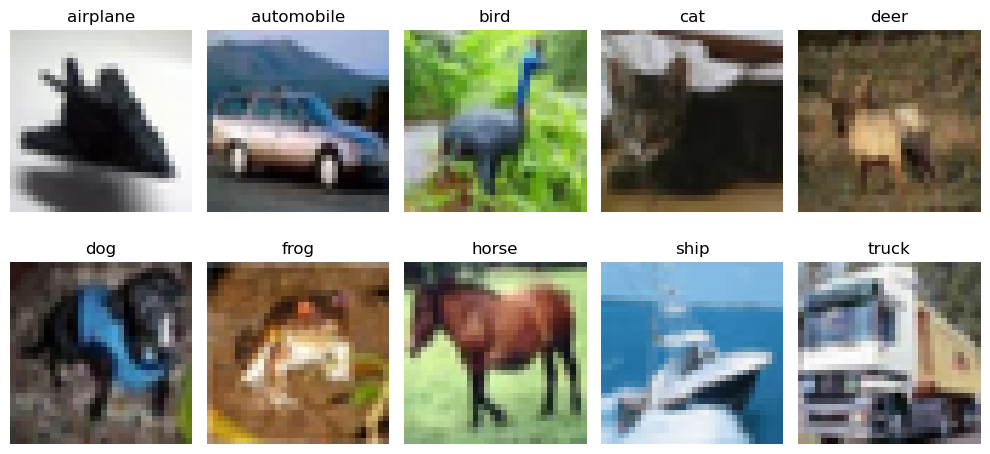

In [16]:
# Flatten labels for visualization
y_train = y_train.flatten()

# Class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Create the plot
plt.figure(figsize=(10, 5))
# Select an image for each class
for class_id in range(10):
    index = np.where(y_train == class_id)[0][0]
    # Plot the imaage
    plt.subplot(2, 5, class_id + 1)
    plt.imshow(X_train[index])
    plt.title(class_names[class_id])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
# Preprocessing
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

X_train = X_train.reshape(len(X_train), -1)
X_test = X_test.reshape(len(X_test), -1)

In [18]:
X_train.shape

(50000, 3072)

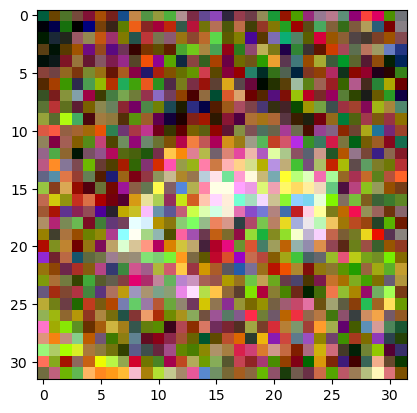

In [19]:
# Random Noise
noise_factor = 0.2

X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

plt.imshow(X_train_noisy[0].reshape(32, 32, 3))

# <font color= #f6c049> **Modeling** </font>


In [20]:
encoding_dim = 1536

input_img = Input(shape = (3072, ))

# Encoder and Latent Space
d_encoded = Dense(2304, activation='relu')(input_img)
d_encoded = Dense(encoding_dim, activation='relu')(d_encoded)

# Decoder
d_decoded = Dense(2304, activation='relu')(d_encoded)
d_decoded = Dense(3072, activation='sigmoid')(d_decoded)

d_autoencoder = Model(input_img, d_decoded)
d_encoder = Model(input_img, d_encoded)
d_encoded_input = Input(shape=(encoding_dim, ))
d_decode_layer1 = d_autoencoder.layers[-2]
d_decode_layer2 = d_autoencoder.layers[-1]
d_decoder = Model(
    d_encoded_input,
    d_decode_layer2(d_decode_layer1(d_encoded_input)))

In [21]:
d_autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2304)           │     7,080,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1536)           │     3,540,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2304)           │     3,541,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3072)           │     7,080,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,242,880 (81.04 MB)

 Trainable params: 21,242,880 (81.04 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
d_autoencoder.compile(optimizer='adam',
                      loss='binary_crossentropy', metrics=['accuracy'])

history = d_autoencoder.fit(
    X_train_noisy, X_train, epochs=5, validation_data=(X_test_noisy, X_test), batch_size=128
    )

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.0031 - loss: 0.6238 - val_accuracy: 0.0034 - val_loss: 0.5987
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.0047 - loss: 0.5914 - val_accuracy: 0.0057 - val_loss: 0.5893
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.0063 - loss: 0.5847 - val_accuracy: 0.0061 - val_loss: 0.5847
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.0072 - loss: 0.5817 - val_accuracy: 0.0087 - val_loss: 0.5816
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.0083 - loss: 0.5791 - val_accuracy: 0.0079 - val_loss: 0.5794


In [23]:
encoded_images = d_encoder.predict(X_test_noisy)
reconstruct = d_decoder.predict(encoded_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


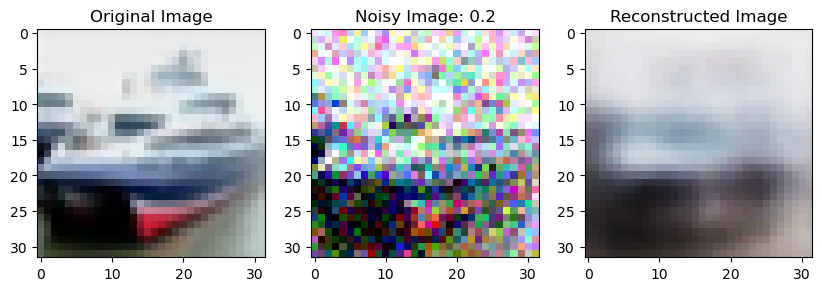

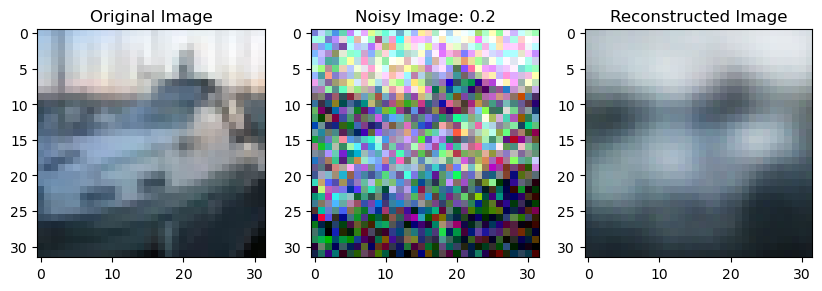

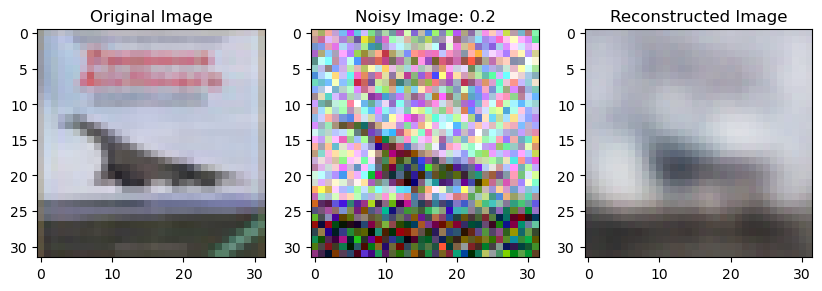

In [24]:
def plot_imgs_for_cnn_noisy(index=0):
  f = plt.figure(figsize=(10, 10))
  f.add_subplot(1,3, 1)
  plt.imshow(X_test[index].reshape(32, 32, 3))
  plt.title("Original Image")

  f.add_subplot(1,3,2)
  plt.imshow(X_test_noisy[index].reshape(32,32,3))
  plt.title(f"Noisy Image: {noise_factor}")


  f.add_subplot(1,3, 3)
  plt.imshow(reconstruct[index].reshape(32,32, 3))
  plt.title("Reconstructed Image")

plot_imgs_for_cnn_noisy(1)
plot_imgs_for_cnn_noisy(2)
plot_imgs_for_cnn_noisy(3)

# <font color= #f6c049> **Bibliography and References** </font>

[1] Krizhevsky, A. (2009). _Learning Multiple Layers of Features from Tiny Images_. **University of Toronto**. https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf